## Importing Libraries

In [20]:
import os
import librosa
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.image import resize
import matplotlib.pyplot as plt
import seaborn as sns

### Vizualiziranje jedinstvene audio datoteke

In [21]:
random_file_name = "archive(1)/Data/genres_original/metal/metal.00000.wav"

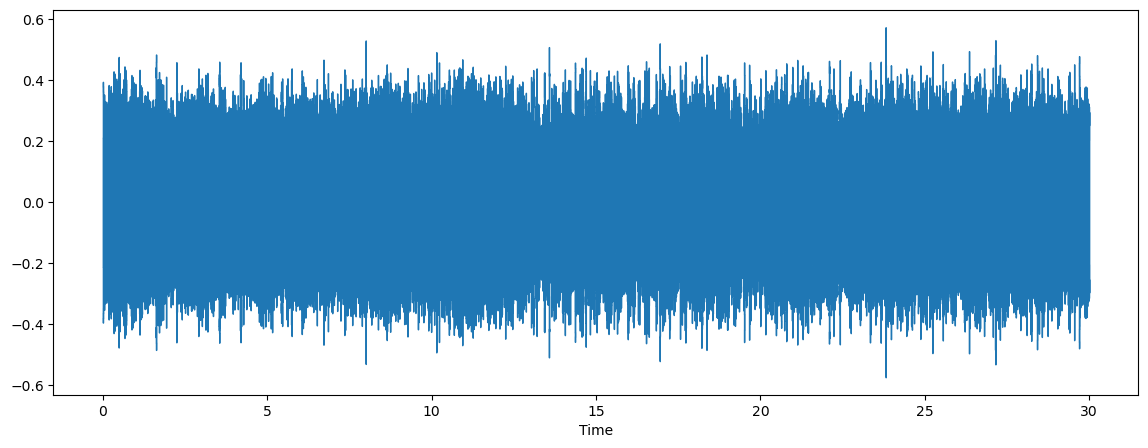

In [22]:
x, sr = librosa.load(random_file_name, sr=44100) #sample rate- koliko puta u sekundi uzima "sliku" zvuka
plt.figure(figsize=(14, 5))
librosa.display.waveshow(x, sr=sr)

#### Zvuk

In [23]:
from IPython.display import Audio
Audio(data=x, rate=sr)

### Vizualizacija odlomaka spomenute audio datoteke

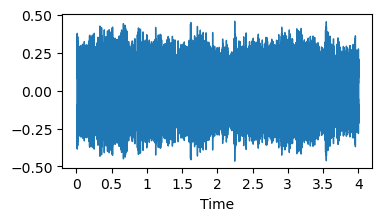

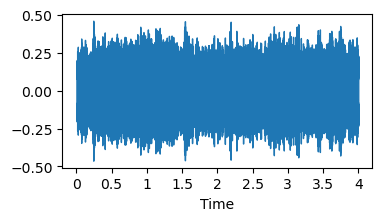

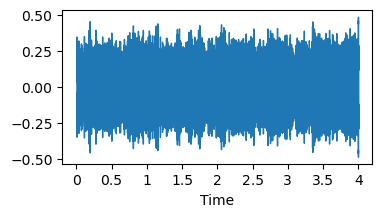

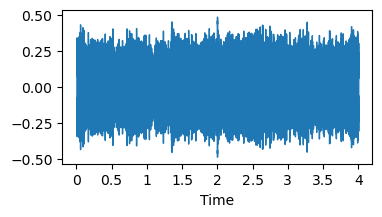

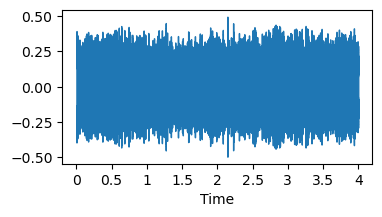

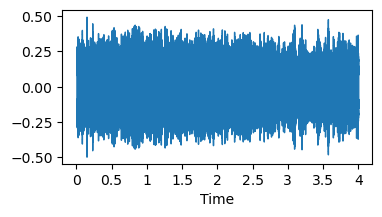

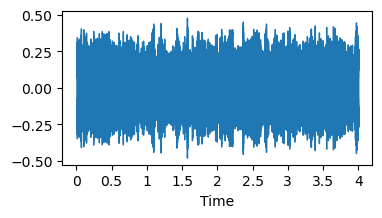

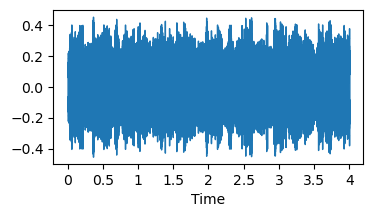

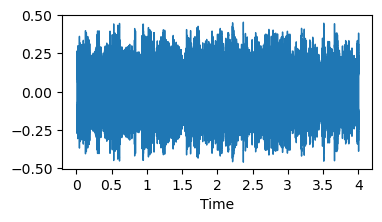

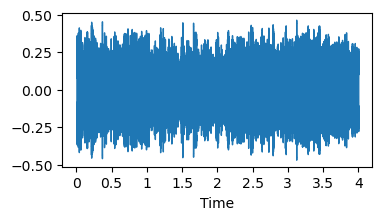

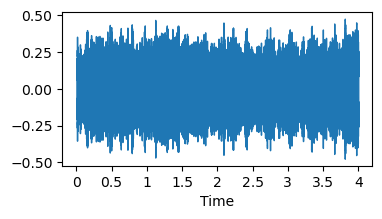

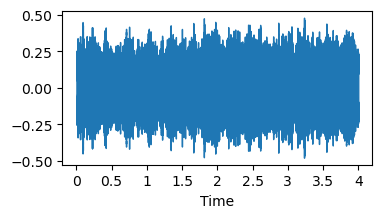

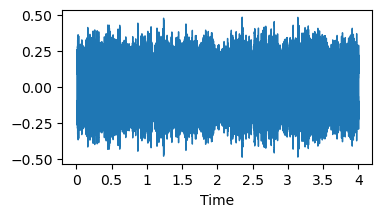

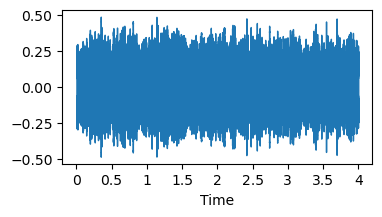

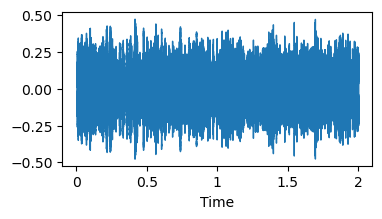

In [24]:
audio_path = "archive(1)/Data/genres_original/metal/metal.00000.wav"
y, sr = librosa.load(audio_path, sr=None)  # sr=None tako da sampling rate bude jednak originalu

# Definiranje trajanje svakog odlomka i preklapanja
chunk_duration = 4  # sekunde
overlap_duration = 2  # sekunde

# Pretvaranje duljine u uzorke
chunk_samples = chunk_duration * sr
overlap_samples = overlap_duration * sr

# Izračun broja odlomaka
num_chunks = int(np.ceil((len(y) - chunk_samples) / (chunk_samples - overlap_samples))) + 1

# Iteracije svakog odlomka
for i in range(num_chunks):
    # Izračun početnog i završnog indeksa odlomka
    start = i * (chunk_samples - overlap_samples)
    end = start + chunk_samples
    
    # Izdvajanje odlomka audio datoteke
    chunk = y[start:end]
    plt.figure(figsize=(4, 2))
    librosa.display.waveshow(chunk, sr=sr)
    plt.show()

### Melspektrogram vizualizacija

In [25]:
#Mapiranje Melspektograma kompletne zvučne datoteke
def plot_melspectrogram(y,sr):
    # Izračun spektograma
    spectrogram = librosa.feature.melspectrogram(y=y, sr=sr)
    # Pretvaranjje u decibele (log scale)
    spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)
    # Vizualizacija spektograma
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(spectrogram_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Spektrogram')
    plt.tight_layout()
    plt.show()

In [26]:
def plot_melspectrogram_chunks(y,sr):
    # Definiranje trajanje svakog odlomka i preklapanja
    chunk_duration = 4  # sekunde
    overlap_duration = 2  # sekunde
    
    # Pretvaranje duljine u uzorke
    chunk_samples = chunk_duration * sr
    overlap_samples = overlap_duration * sr
    
    # Izračun broja odlomaka
    num_chunks = int(np.ceil((len(y) - chunk_samples) / (chunk_samples - overlap_samples))) + 1
    
    # Iteracije svakog odlomka
    for i in range(num_chunks):
        # Izračun početnog i završnog indeksa odlomka
        start = i * (chunk_samples - overlap_samples)
        end = start + chunk_samples
        
        # Izdvajanje odlomka audio datoteke
        chunk = y[start:end]
        
        # Izračun Melspektograma za odlomke
        mel_spectrogram = librosa.feature.melspectrogram(y=chunk, sr=sr)
        print(mel_spectrogram.shape)
        spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
        # Vizualiziraj spektogram
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(spectrogram_db, sr=sr, x_axis='time', y_axis='mel')
        plt.colorbar(format='%+2.0f dB')
        plt.title('Spektrogram')
        plt.tight_layout()
        plt.show()

(128, 173)


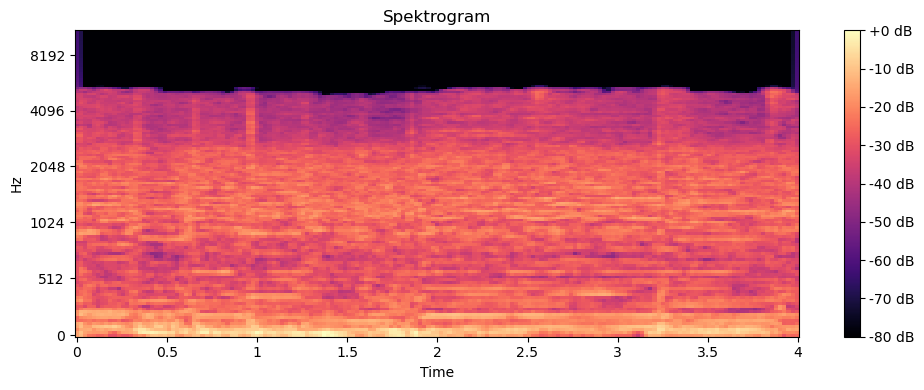

(128, 173)


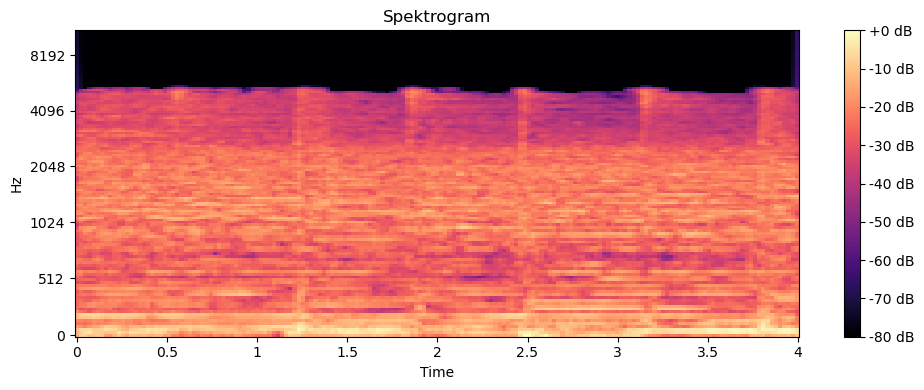

(128, 173)


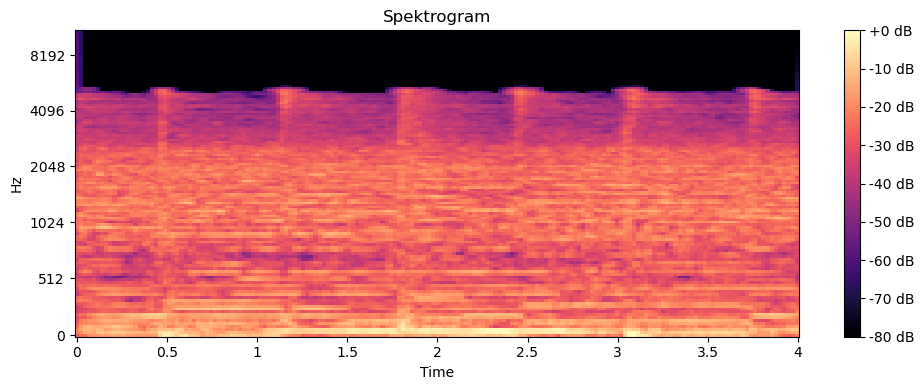

(128, 173)


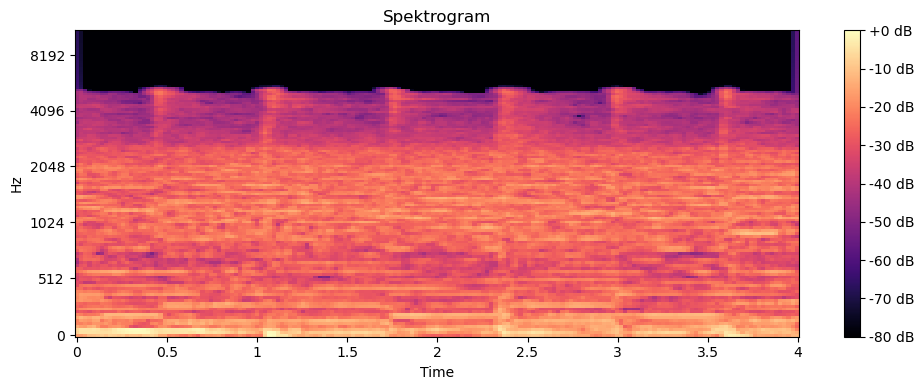

(128, 173)


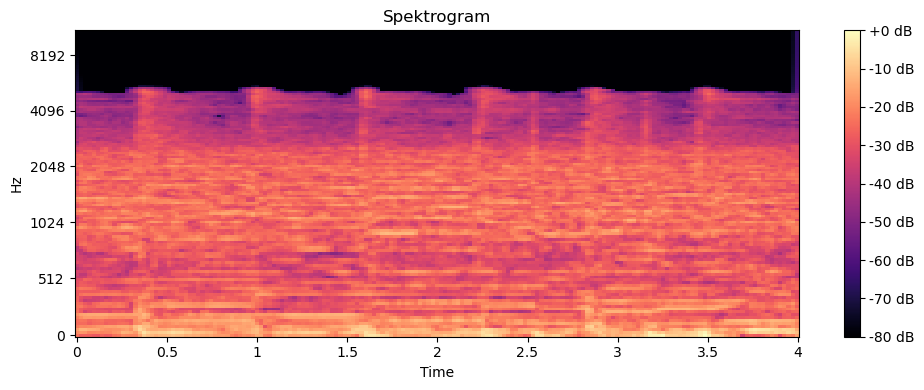

(128, 173)


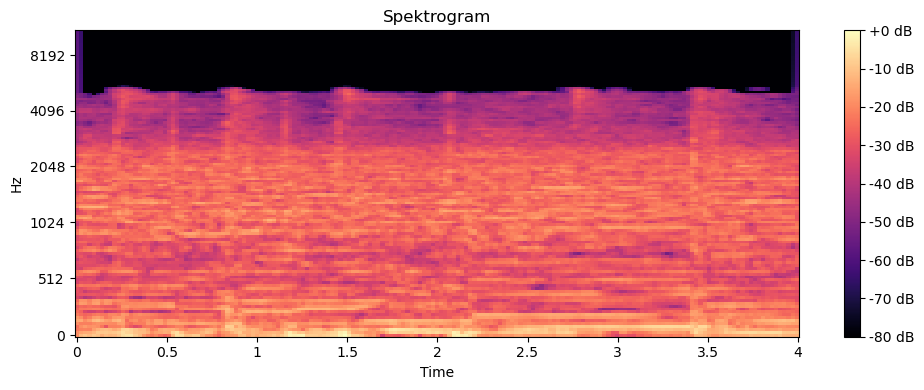

(128, 173)


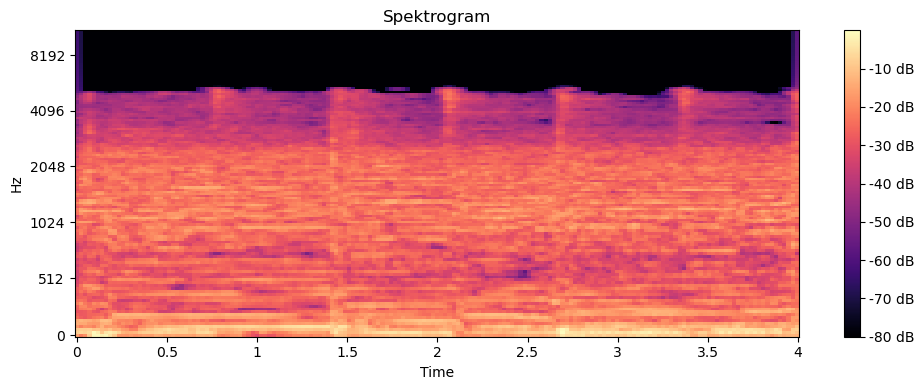

(128, 173)


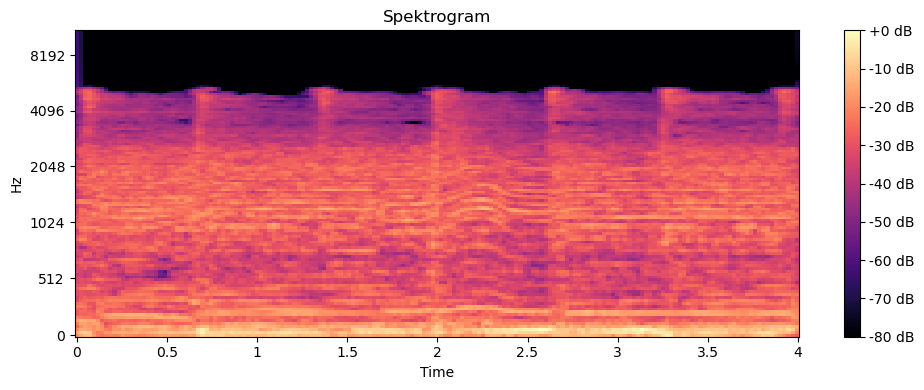

(128, 173)


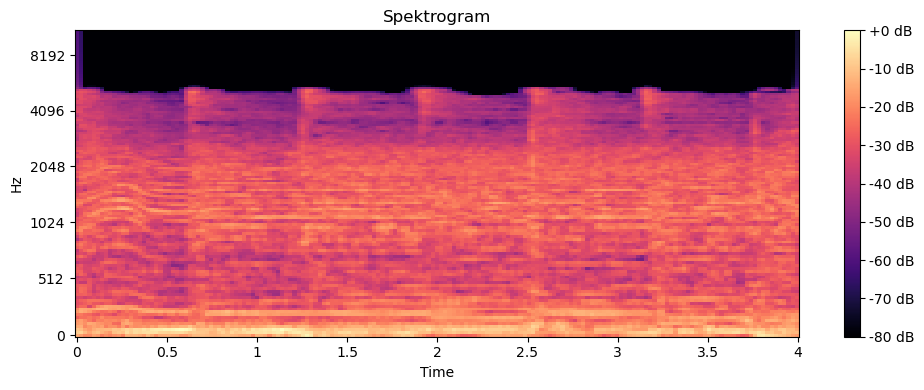

(128, 173)


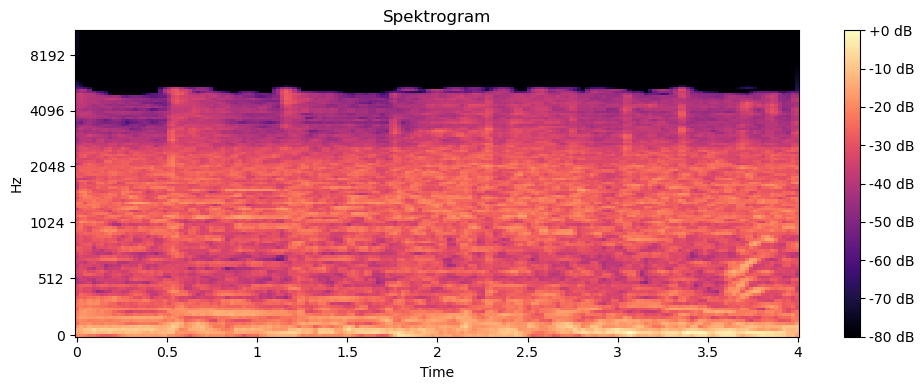

(128, 173)


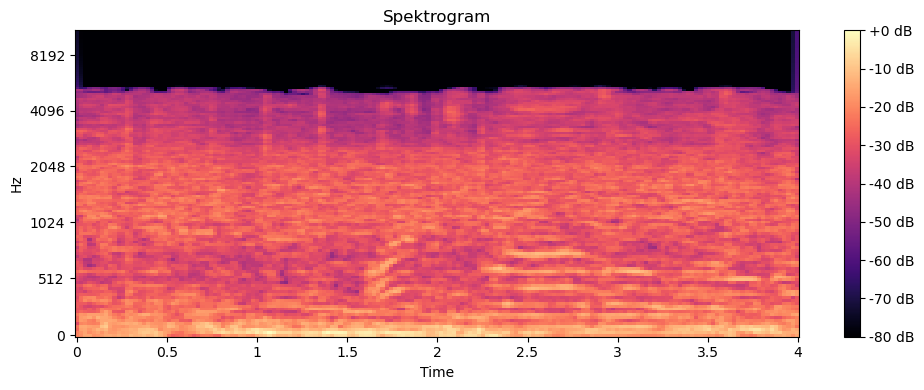

(128, 173)


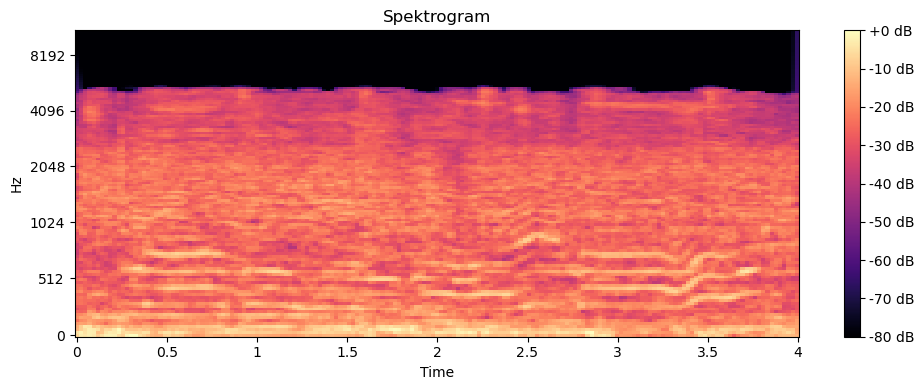

(128, 173)


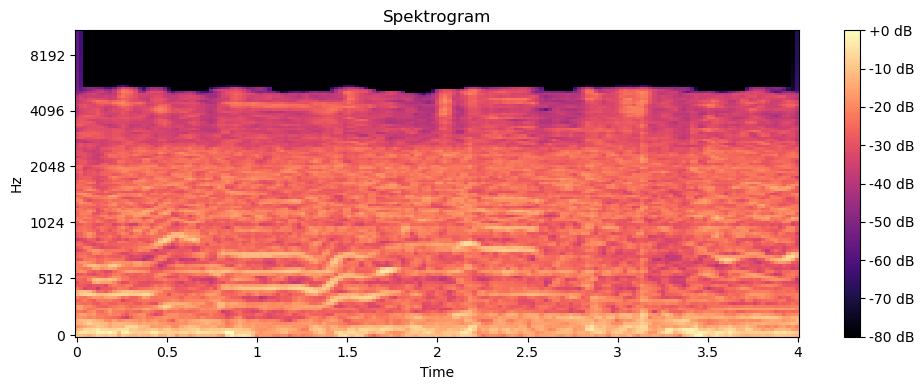

(128, 173)


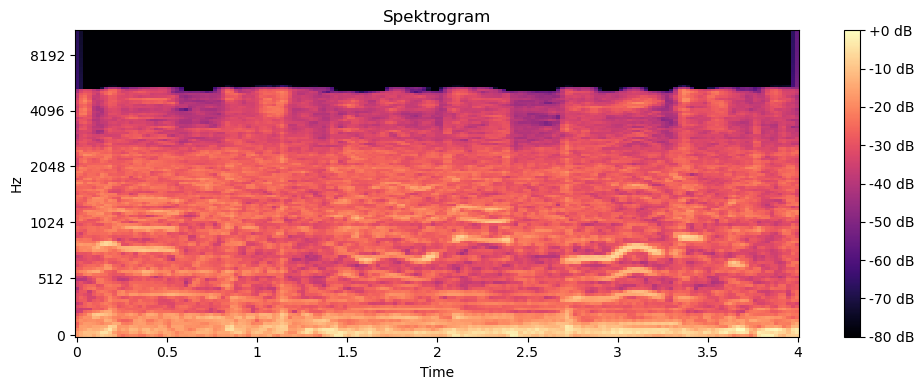

(128, 173)


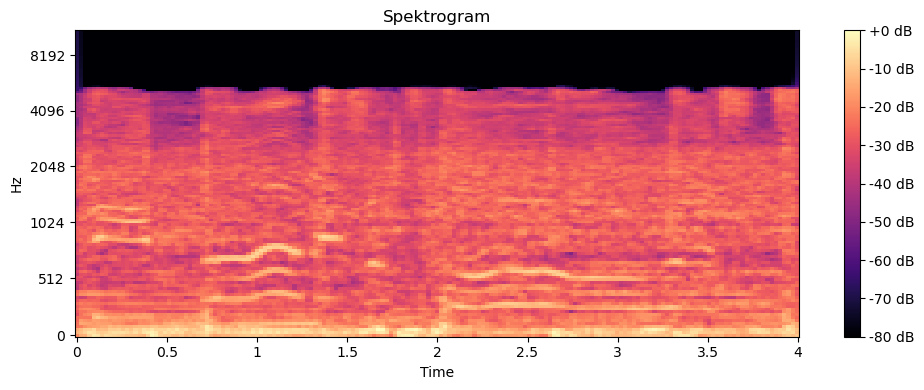

(128, 173)


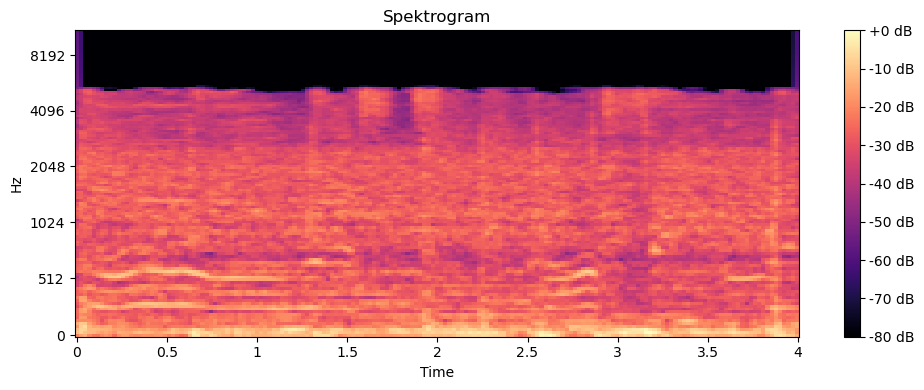

(128, 173)


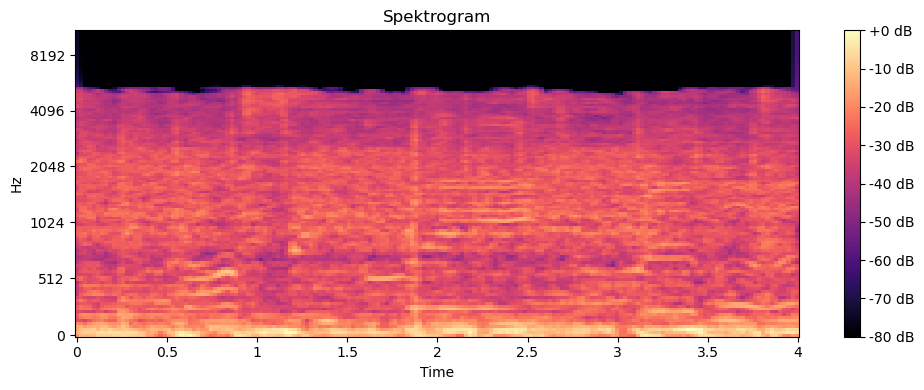

(128, 173)


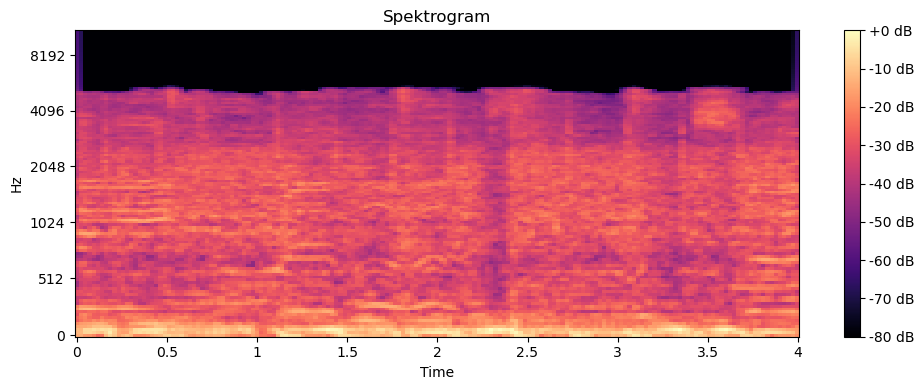

(128, 173)


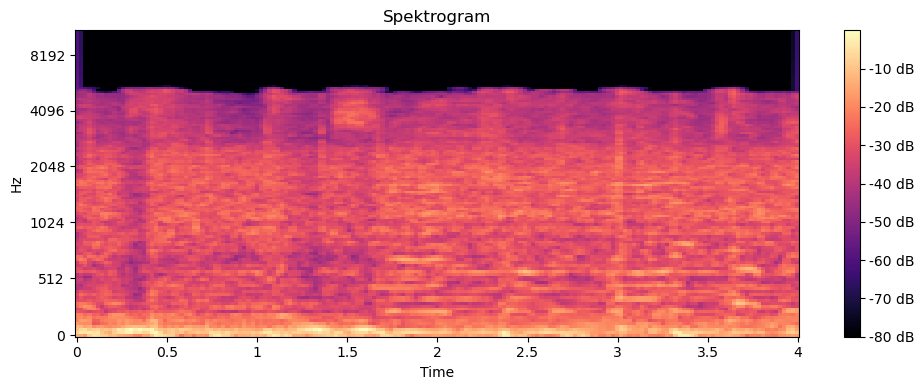

(128, 173)


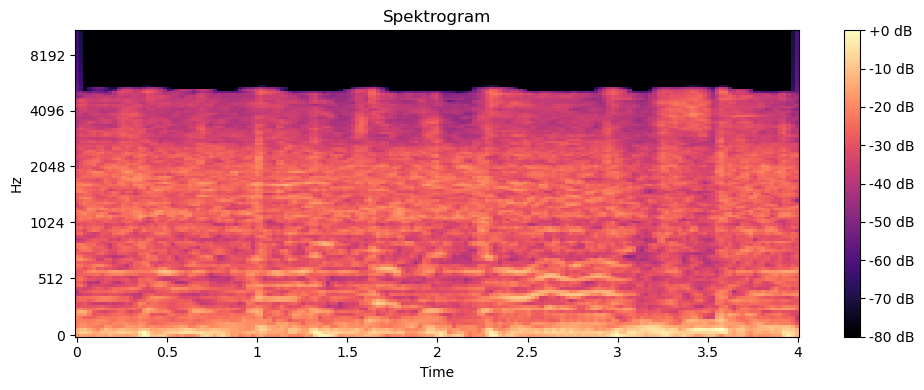

(128, 173)


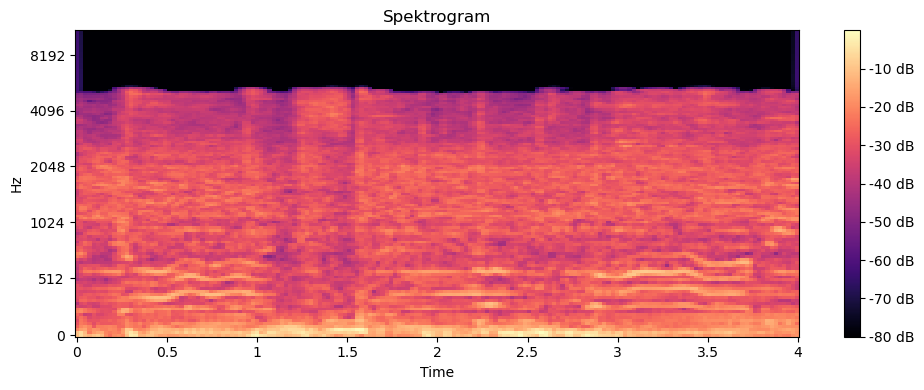

(128, 173)


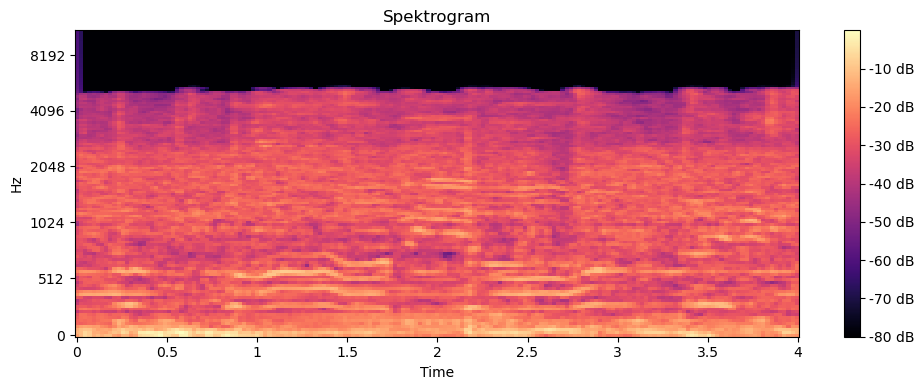

(128, 173)


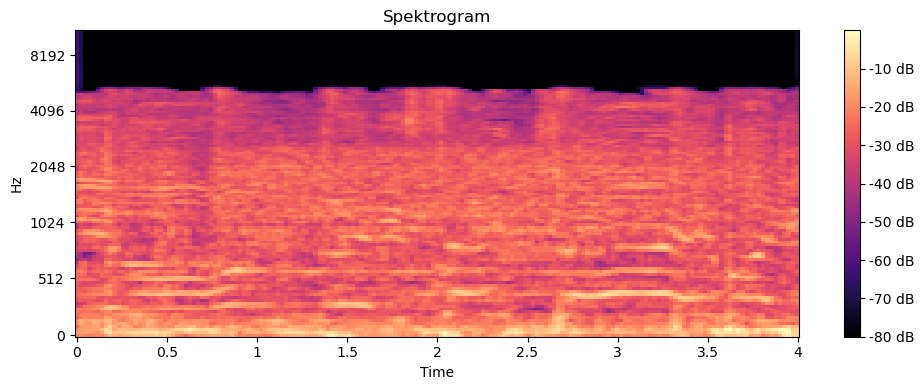

(128, 173)


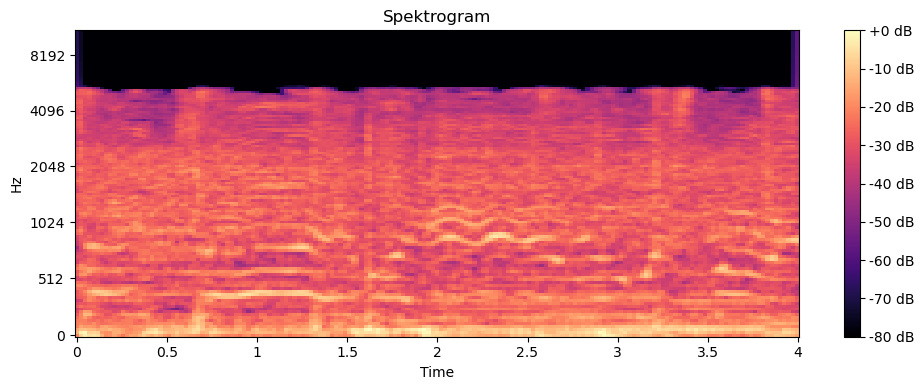

(128, 173)


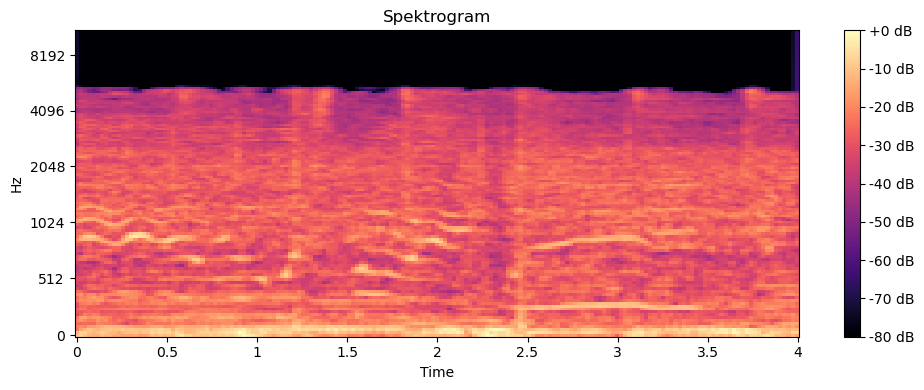

(128, 173)


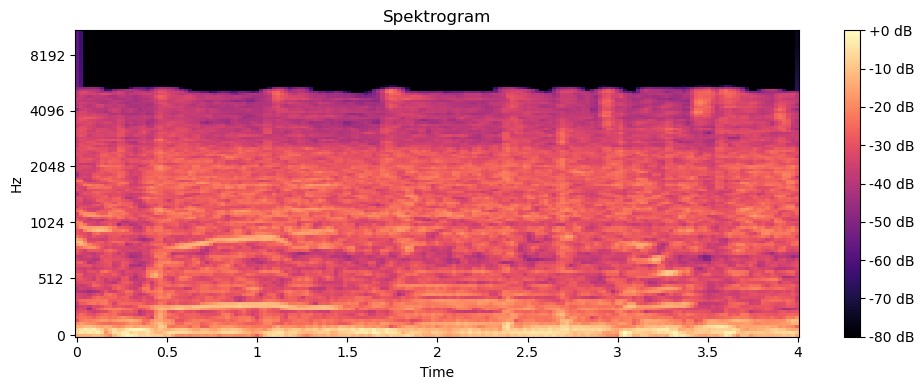

(128, 173)


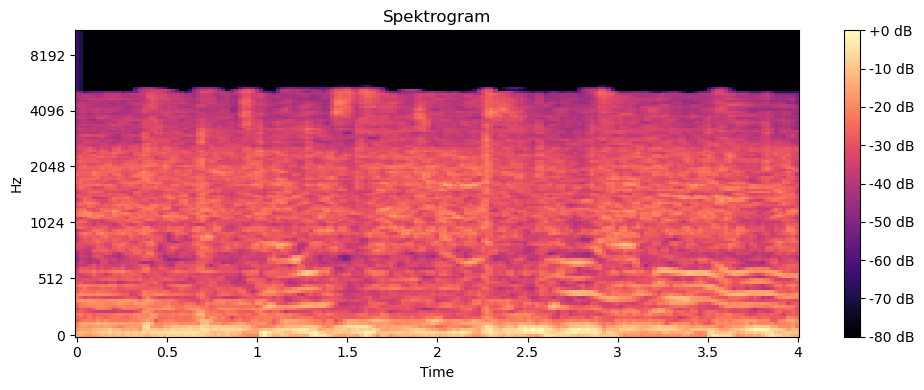

(128, 173)


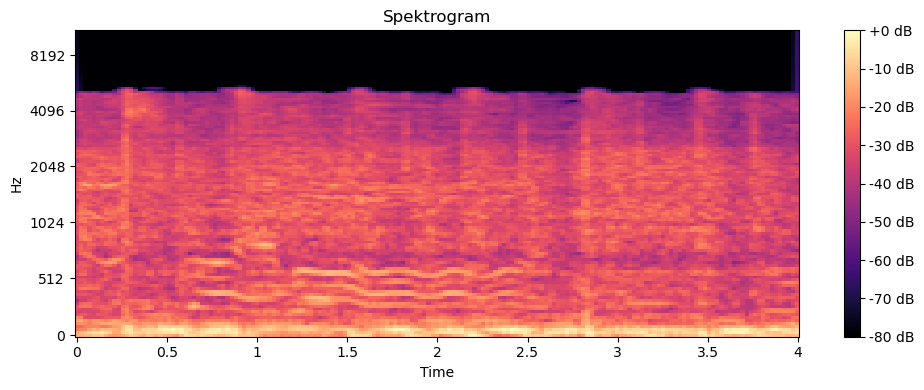

(128, 173)


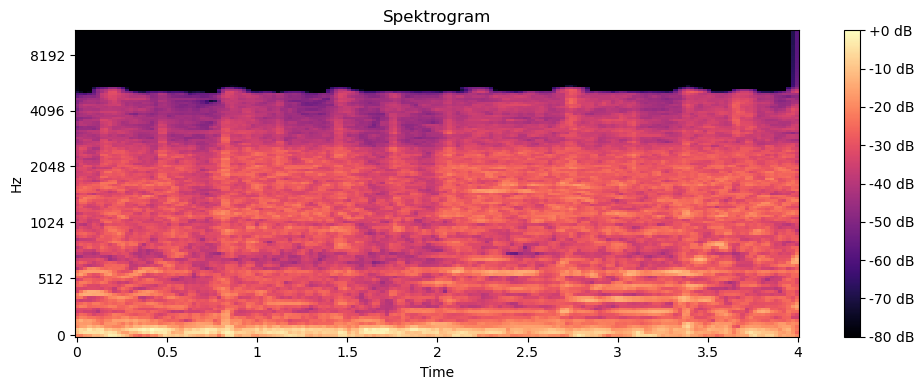

(128, 87)


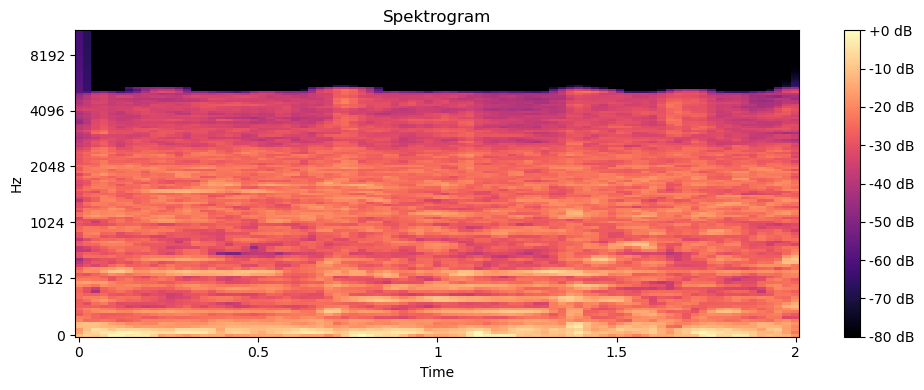

In [27]:
#Spektrogram of zvučnih djelova
plot_melspectrogram_chunks(y=x,sr=sr)

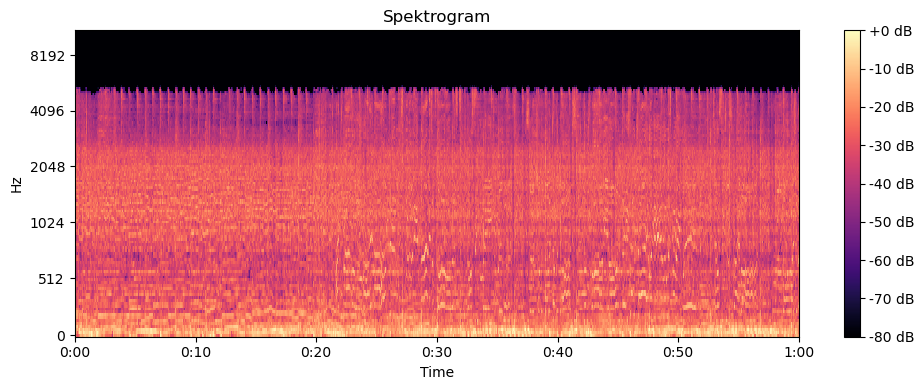

In [28]:
#Spektrogram of čitave audio datoteke
plot_melspectrogram(y=x,sr=sr)

### Predobrada podataka

In [10]:
data_dir = 'archive(1)/Data/genres_original'
classes = ['jazz','hiphop','disco','country','blues','classical','metal','pop','reggae','rock']

In [11]:
# Učitavanje i predobrada audio podataka
def load_and_preprocess_data(data_dir, classes, target_shape=(150, 150)):
    data = []
    labels = []
    
    for i_class, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        print("Processing--",class_name)
        for filename in os.listdir(class_dir):
            if filename.endswith('.wav'):
                file_path = os.path.join(class_dir, filename)
                audio_data, sample_rate = librosa.load(file_path, sr=None)
                # Predobrada (npr., pretvoriti u Melspektogram i promijeniti veličinu)
                # Definiranje trajanja svakog odjeljka i preklopa
                chunk_duration = 4  # sekunde
                overlap_duration = 2  # sekunde
                
                # Pretvaranje duljina u odjeljke
                chunk_samples = chunk_duration * sample_rate
                overlap_samples = overlap_duration * sample_rate
                
                # Izračun broja odjeljaka
                num_chunks = int(np.ceil((len(audio_data) - chunk_samples) / (chunk_samples - overlap_samples))) + 1
                
                # Iteracija svakog odjeljka
                for i in range(num_chunks):
                    # Izračun početnog i završnog indeksa odlomka
                    start = i * (chunk_samples - overlap_samples)
                    end = start + chunk_samples
                    
                    # Izdvajanje odjeljka audio datoteke
                    chunk = audio_data[start:end]
                    
                    # Izračun Melspektograma za odlomke
                    mel_spectrogram = librosa.feature.melspectrogram(y=chunk, sr=sr)
                    
                #mel_spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sample_rate)
                    mel_spectrogram = resize(np.expand_dims(mel_spectrogram, axis=-1), target_shape)
                    data.append(mel_spectrogram)
                    labels.append(i_class)
    
    return np.array(data), np.array(labels)

In [12]:
# Podjela na trening i test
data, labels = load_and_preprocess_data(data_dir, classes)
#print("\nData:",data,"\nlabel",labels)

Processing-- jazz
Processing-- hiphop
Processing-- disco
Processing-- country
Processing-- blues
Processing-- classical
Processing-- metal
Processing-- pop
Processing-- reggae
Processing-- rock


In [13]:
data.shape

(14975, 150, 150, 1)

In [14]:
labels.shape

(14975,)

In [15]:
labels

array([0, 0, 0, ..., 9, 9, 9])

In [16]:
labels = to_categorical(labels, num_classes=len(classes))  # Pretvaranje oznaka u one-hot encoding
labels

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [17]:
labels.shape

(14975, 10)

In [18]:
data.shape

(14975, 150, 150, 1)

### Podjela dataseta na trening set i test set

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

## Model izgradnje

In [20]:
model = tf.keras.models.Sequential()

In [21]:
X_train[0].shape

(150, 150, 1)

In [22]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=X_train[0].shape))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

C:\Users\FOIStudent\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [24]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [25]:
model.add(tf.keras.layers.Dropout(0.3))

In [26]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [27]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [28]:
model.add(Dropout(0.3))

In [29]:
model.add(Flatten())

In [30]:
model.add(Dense(units=1200,activation='relu'))

In [31]:
model.add(Dropout(0.45))

In [32]:
#Output sloj
model.add(Dense(units=len(classes),activation='softmax'))

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 148, 148, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 74, 74, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 17, 17, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 5, 5, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1200)           │     2,458,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,182,458 (27.40 MB)

 Trainable params: 7,182,458 (27.40 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Compile modela
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [35]:
X_train.shape,y_train.shape

((11980, 150, 150, 1), (11980, 10))

In [36]:
# Trening modela
training_history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 269s 706ms/step - accuracy: 0.2632 - loss: 1.9870 - val_accuracy: 0.4087 - val_loss: 1.6305
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 271s 723ms/step - accuracy: 0.4952 - loss: 1.4131 - val_accuracy: 0.5349 - val_loss: 1.3281
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 273s 729ms/step - accuracy: 0.6061 - loss: 1.1452 - val_accuracy: 0.6327 - val_loss: 1.0642
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 266s 709ms/step - accuracy: 0.6677 - loss: 0.9638 - val_accuracy: 0.6932 - val_loss: 0.9006
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 266s 709ms/step - accuracy: 0.7139 - loss: 0.8366 - val_accuracy: 0.7346 - val_loss: 0.7891
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 268s 716ms/step - accuracy: 0.7543 - loss: 0.7222 - val_accuracy: 0.7619 - val_loss: 0.7237
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 266s 709ms/step - accuracy: 0.7940 - loss: 0.6131 - val_accuracy: 0.7756 - val_loss: 0.6422
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 265s 706ms/step - accuracy: 0.8232 -

In [37]:
model.save("Trained_model.keras") #novi model, nije legacy

In [38]:
training_history.history

{'accuracy': [0.2631886601448059,
  0.4951585829257965,
  0.6060934662818909,
  0.6676961779594421,
  0.713939905166626,
  0.754257082939148,
  0.7939899563789368,
  0.8232053518295288,
  0.8469114899635315,
  0.868948221206665,
  0.8790484070777893,
  0.9049248695373535,
  0.9192821383476257,
  0.9308013319969177,
  0.9380634427070618,
  0.9429883360862732,
  0.95350581407547,
  0.9598497748374939,
  0.9543405771255493,
  0.9590150117874146,
  0.9685308933258057,
  0.9767112135887146,
  0.9714524149894714,
  0.9702003598213196,
  0.9751251935958862,
  0.9746243953704834,
  0.9808013439178467,
  0.9805509448051453,
  0.9823873043060303,
  0.9797161817550659],
 'loss': [1.9870363473892212,
  1.4131308794021606,
  1.145189642906189,
  0.9637875556945801,
  0.8366180062294006,
  0.7221680283546448,
  0.6131076812744141,
  0.5265452265739441,
  0.44634607434272766,
  0.3839888274669647,
  0.3482144773006439,
  0.28183281421661377,
  0.23872512578964233,
  0.20970997214317322,
  0.181211099

In [39]:
#Spremanje povijesti u json obliku
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

### Evaluacija modela

In [40]:
##Evaluacija modela na trening setu
train_accuracy=model.evaluate(X_train,y_train,verbose=0)
print(train_accuracy[1])

0.9945743083953857


In [41]:
##Evaluacija modela na test setu
test_accuracy=model.evaluate(X_test,y_test,verbose=0)
print(test_accuracy[1])

0.9095158576965332


### Vizualizacija točnosti i gubitka

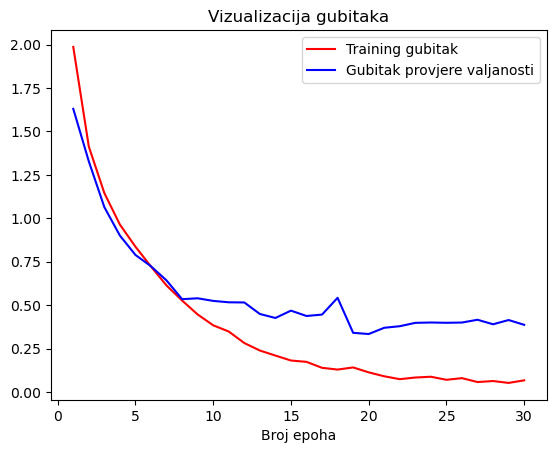

In [42]:
#Vizualizacija gubitaka
epochs = [i for i in range(1,31)]
plt.plot(epochs,training_history.history['loss'],color='red',label='Training gubitak')
plt.plot(epochs,training_history.history['val_loss'],color='blue',label='Gubitak provjere valjanosti')
plt.xlabel('Broj epoha')
plt.title('Vizualizacija gubitaka')
plt.legend()
plt.show()

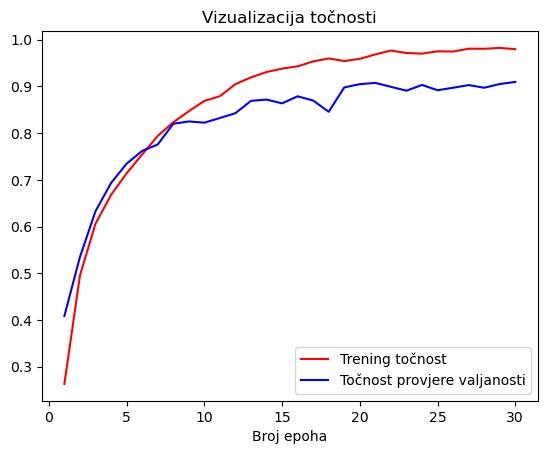

In [43]:
#Vizualizacija točnosti
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Trening točnost')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Točnost provjere valjanosti')
plt.xlabel('Broj epoha')
plt.title('Vizualizacija točnosti')
plt.legend()
plt.show()

### Izračun metrika preciznosti, prisjećanja i zbunjenosti

In [44]:
y_pred = model.predict(X_test)
y_pred

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step


array([[2.0526006e-06, 7.4196851e-04, 3.2472897e-05, ..., 9.9865258e-01,
        1.6961514e-05, 3.8303662e-04],
       [1.5327002e-12, 1.0981125e-11, 1.8166981e-14, ..., 1.1973454e-17,
        1.6470443e-15, 2.9231956e-06],
       [2.6680008e-12, 2.6660282e-11, 1.7263435e-16, ..., 7.2666629e-13,
        7.0174198e-15, 3.0938936e-06],
       ...,
       [9.9875760e-01, 2.4039039e-07, 9.3983754e-10, ..., 2.7887924e-07,
        3.2929883e-08, 1.1949903e-06],
       [3.0350061e-13, 9.9999988e-01, 5.4673549e-08, ..., 7.1328801e-09,
        4.4851464e-10, 4.6711590e-10],
       [1.7208875e-07, 2.3783234e-11, 6.5767304e-06, ..., 9.1762885e-08,
        4.1694768e-09, 8.0933837e-08]], dtype=float32)

In [45]:
y_pred.shape

(2995, 10)

In [46]:
y_test.shape

(2995, 10)

In [47]:
predicted_categories = np.argmax(y_pred, axis=1)
predicted_categories

array([7, 6, 6, ..., 0, 1, 4], dtype=int64)

In [48]:
y_test

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [49]:
true_categories = np.argmax(y_test, axis=1)
true_categories

array([7, 6, 6, ..., 0, 1, 4], dtype=int64)

In [50]:
classes

['jazz',
 'hiphop',
 'disco',
 'country',
 'blues',
 'classical',
 'metal',
 'pop',
 'reggae',
 'rock']

In [51]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(true_categories,predicted_categories)
# Precision Recall F1score
print(classification_report(true_categories,predicted_categories,target_names=classes))

              precision    recall  f1-score   support

        jazz       0.91      0.95      0.93       296
      hiphop       0.94      0.91      0.92       297
       disco       0.93      0.90      0.92       323
     country       0.85      0.88      0.86       308
       blues       0.88      0.94      0.91       282
   classical       0.94      0.94      0.94       311
       metal       0.94      0.97      0.96       302
         pop       0.96      0.80      0.87       289
      reggae       0.96      0.91      0.93       296
        rock       0.81      0.90      0.85       291

    accuracy                           0.91      2995
   macro avg       0.91      0.91      0.91      2995
weighted avg       0.91      0.91      0.91      2995



### Vizualizacija matrice konfuzije

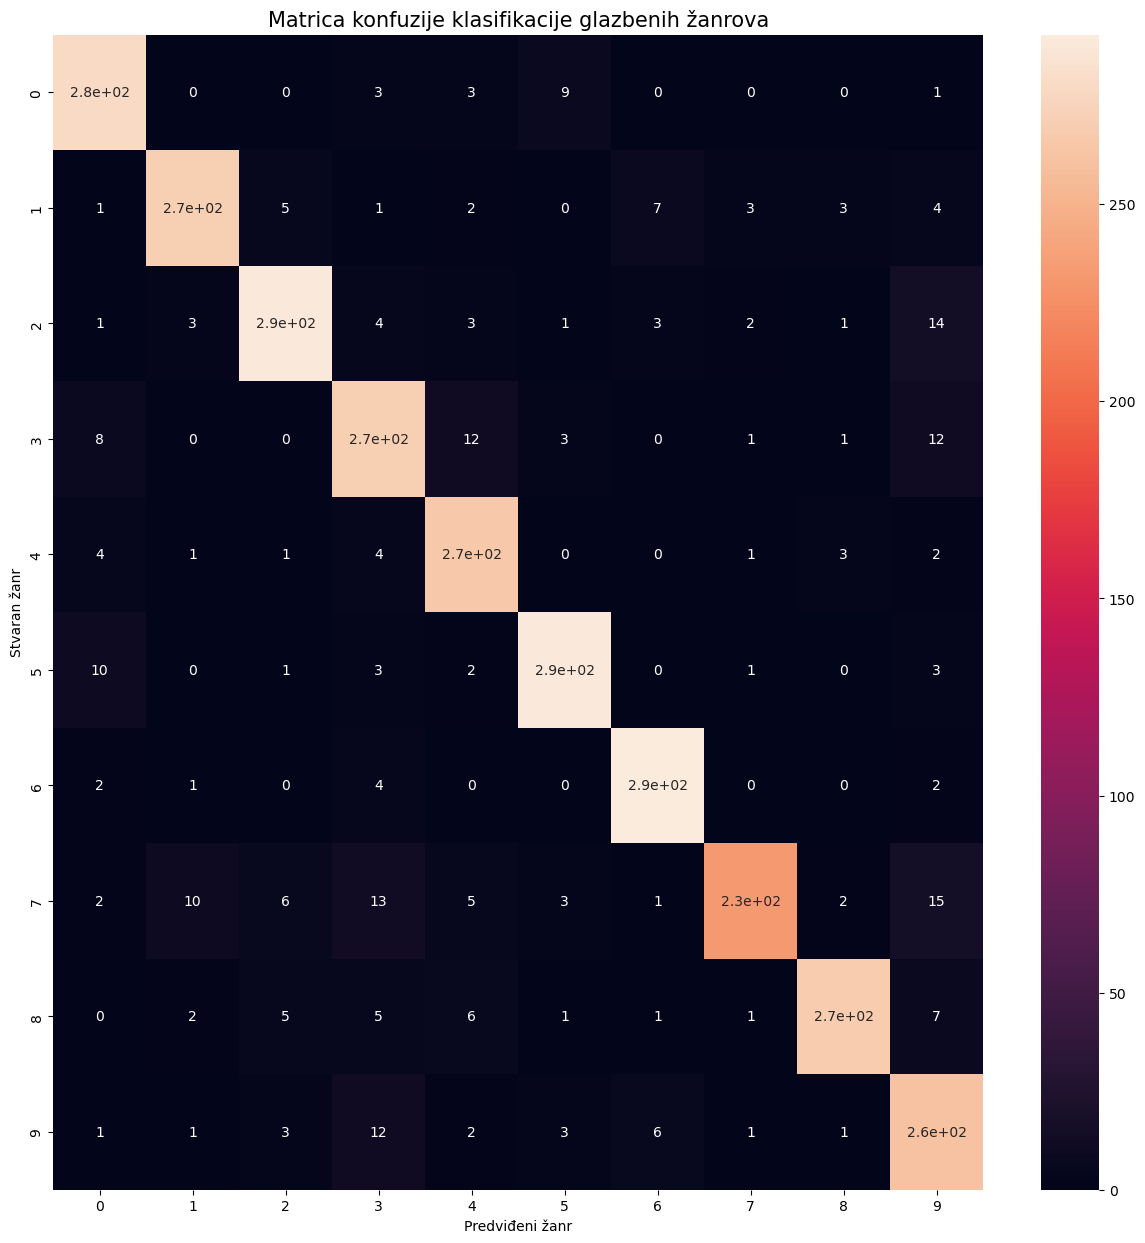

In [52]:
plt.figure(figsize=(15, 15))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predviđeni žanr',fontsize = 10)
plt.ylabel('Stvaran žanr',fontsize = 10)
plt.title('Matrica konfuzije klasifikacije glazbenih žanrova',fontsize = 15)
plt.show()